In [1]:
import torch
from Detanet.detanet_model import nn_vib_analysis,Lorenz_broadening,DetaNet,get_raman_intensity,uv_model,nmr_calculator,nmr_sca,charge_model

In [2]:
device=torch.device('cuda')
dtype=torch.float32

In [3]:
import torch
import re

# 提取pos和z的函数
def extract_pos_z(output):
    # 使用正则表达式从文本中提取pos和z
    pos_match = re.search(r'pos tensor: (\[\[.*?\]\])', output)
    z_match = re.search(r'z tensor: (\[.*?\])', output)
    
    # 提取pos和z的列表
    pos_tensor = eval(pos_match.group(1)) if pos_match else []
    z_tensor = eval(z_match.group(1)) if z_match else []

    # 将pos tensor中的字符串数字转换为float类型
    for i, item in enumerate(pos_tensor):
        # 将字符串数字转换为浮点数
        pos_tensor[i] = [float(coord) for coord in item]
    
    # 转为torch.tensor
    pos_tensor = torch.tensor(pos_tensor, dtype=torch.float32) if pos_tensor else torch.tensor([], dtype=torch.float32)
    z_tensor = torch.LongTensor(z_tensor) if z_tensor else torch.LongTensor([])

    return pos_tensor, z_tensor

# 测试数据
data = {
    "Generated Output": "pos tensor: [['2.0146e-02', '1.3511e+00', '1.3154e-01'], ['-4.8882e-02', '-3.3000e-04', '4.0800e-03'], ['-1.1300e+00', '-7.5069e-01', '7.2950e-03'], ['-6.3900e-01', '-2.1053e+00', '-1.2211e-02'], ['6.9516e-01', '-2.1028e+00', '-1.9688e-02'], ['1.1120e+00', '-3.1028e+00', '-3.3211e-02'], ['1.1482e+00', '-8.0502e-01', '-9.5220e-03'], ['9.0696e-01', '1.7333e+00', '-1.0881e-01'], ['-7.6062e-01', '1.8595e+00', '-3.2808e-02'], ['-2.1752e+00', '-5.2113e-01', '1.5070e-02'], ['2.1030e+00', '-6.2558e-01', '-1.0403e-02']]\nz tensor: [7, 6, 7, 6, 7, 6, 7, 1, 1, 1, 1]",
        "Actual Output": "pos tensor: [['-1.6008e-02', '1.3292e+00', '8.0590e-03'], ['2.2560e-03', '-1.7016e-02', '8.0800e-04'], ['-1.1821e+00', '-6.5826e-01', '4.1640e-03'], ['-1.0885e+00', '-1.9790e+00', '-3.3930e-03'], ['3.8581e-02', '-2.6947e+00', '-1.3585e-02'], ['1.1458e+00', '-1.9486e+00', '-1.5936e-02'], ['1.2036e+00', '-6.2582e-01', '-9.2700e-03'], ['8.5121e-01', '1.8363e+00', '5.7480e-03'], ['-8.9667e-01', '1.8126e+00', '1.5599e-02'], ['-2.0221e+00', '-2.5326e+00', '-9.5300e-04'], ['2.0941e+00', '-2.4766e+00', '-2.4152e-02']]\nz tensor: [7, 6, 7, 6, 7, 6, 7, 1, 1, 1, 1]"
}

# 提取Generated Output的pos和z
generated_pos, generated_z = extract_pos_z(data['Generated Output'])
print("Generated pos:", generated_pos)
print("Generated z:", generated_z)

# 提取Actual Output的pos和z
actual_pos, actual_z = extract_pos_z(data['Actual Output'])
print("Actual pos:", actual_pos)
print("Actual z:", actual_z)



Generated pos: tensor([[ 2.0146e-02,  1.3511e+00,  1.3154e-01],
        [-4.8882e-02, -3.3000e-04,  4.0800e-03],
        [-1.1300e+00, -7.5069e-01,  7.2950e-03],
        [-6.3900e-01, -2.1053e+00, -1.2211e-02],
        [ 6.9516e-01, -2.1028e+00, -1.9688e-02],
        [ 1.1120e+00, -3.1028e+00, -3.3211e-02],
        [ 1.1482e+00, -8.0502e-01, -9.5220e-03],
        [ 9.0696e-01,  1.7333e+00, -1.0881e-01],
        [-7.6062e-01,  1.8595e+00, -3.2808e-02],
        [-2.1752e+00, -5.2113e-01,  1.5070e-02],
        [ 2.1030e+00, -6.2558e-01, -1.0403e-02]])
Generated z: tensor([7, 6, 7, 6, 7, 6, 7, 1, 1, 1, 1])
Actual pos: tensor([[-1.6008e-02,  1.3292e+00,  8.0590e-03],
        [ 2.2560e-03, -1.7016e-02,  8.0800e-04],
        [-1.1821e+00, -6.5826e-01,  4.1640e-03],
        [-1.0885e+00, -1.9790e+00, -3.3930e-03],
        [ 3.8581e-02, -2.6947e+00, -1.3585e-02],
        [ 1.1458e+00, -1.9486e+00, -1.5936e-02],
        [ 1.2036e+00, -6.2582e-01, -9.2700e-03],
        [ 8.5121e-01,  1.8363e+00, 

In [4]:
'''Loading model'''
charge_model_=charge_model(device=device)
vib_model=nn_vib_analysis(device=device,Linear=False,scale=0.965)
nmr_model=nmr_calculator(device=device)
uv_model_=uv_model(device=device)

charge_model_

c:\Users\Raytine\.conda\envs\pytorch\Lib\site-packages\torch\jit\_check.py:172: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn("The TorchScript type system doesn't support "


DetaNet(
  (Embedding): Embedding(
    (act): Swish()
    (elec_emb): Linear(in_features=16, out_features=128, bias=False)
    (nuclare_emb): Embedding(10, 128)
    (ls): Linear(in_features=128, out_features=128, bias=True)
  )
  (Radial): Radial_Basis(
    (radial): Bessel_Function()
  )
  (blocks): Sequential(
    (0): Interaction_Block(
      (message): Message(
        (Attention): Edge_Attention(
          (actq): Swish()
          (actk): Swish()
          (actv): Swish()
          (acta): Swish()
          (softmax): Softmax(dim=-1)
          (lq): Linear(in_features=128, out_features=128, bias=True)
          (lk): Linear(in_features=128, out_features=128, bias=True)
          (lv): Linear(in_features=128, out_features=256, bias=True)
          (la): Linear(in_features=256, out_features=256, bias=True)
          (lrbf): Linear(in_features=32, out_features=128, bias=False)
          (lkrbf): Linear(in_features=128, out_features=128, bias=False)
          (lvrbf): Linear(in_featu

In [5]:
'''Caculation of atomic charge'''

z_pre=generated_z
z=actual_z
pos_pre=generated_pos
pos=actual_pos

z=z.to(device)
pos=pos.to(device)
z_pre=z_pre.to(device)
pos_pre=pos_pre.to(device)


charge=charge_model_(z=z, pos=pos)

charge

tensor([[-0.7372],
        [ 0.5281],
        [-0.5018],
        [ 0.2722],
        [-0.4958],
        [ 0.2723],
        [-0.5018],
        [ 0.4046],
        [ 0.4046],
        [ 0.1817],
        [ 0.1817]], device='cuda:0', grad_fn=<MulBackward0>)

In [6]:
# '''Calculation of frequency, IR intensity, Raman activity for each vibration mode. (Units are consistent with Gaussian G16)'''
# freq,iir,araman=vib_model(z=z, pos=pos)
# for i in range(len(freq)):
#     print('Vibration mode:{},Frequency:{:.8f},IR intensity:{:.8f},Raman activity:{:.8f}'
#        .format(i+1,freq[i].item(),iir[i].item(),araman[i].item()))
    
    # Calculate frequency, IR intensity, Raman activity for each vibration mode. (Units are consistent with Gaussian G16)
freq, iir, araman = vib_model(z=z, pos=pos)

freq_pre, iir_pre, araman_pre = vib_model(z=z_pre,pos=pos_pre)

# Replace NaN values in freq with 0
freq = torch.nan_to_num(freq, nan=0.0)

freq_pre = torch.nan_to_num(freq, nan=0.0)

# Print the results
for i in range(len(freq)):
    print('Vibration mode:{}, Frequency:{:.8f}, IR intensity:{:.8f}, Raman activity:{:.8f}'
          .format(i+1, freq[i].item(), iir[i].item(), araman[i].item()))


Vibration mode:1, Frequency:184.22251892, IR intensity:48.45858002, Raman activity:0.02029382
Vibration mode:2, Frequency:259.50158691, IR intensity:178.10862732, Raman activity:0.30324024
Vibration mode:3, Frequency:382.49673462, IR intensity:7.45780039, Raman activity:0.33838767
Vibration mode:4, Frequency:452.63748169, IR intensity:0.00005066, Raman activity:0.44521129
Vibration mode:5, Frequency:506.23724365, IR intensity:0.00022075, Raman activity:1.14569330
Vibration mode:6, Frequency:583.15386963, IR intensity:3.44369745, Raman activity:7.10691977
Vibration mode:7, Frequency:584.14483643, IR intensity:8.85899258, Raman activity:0.21813162
Vibration mode:8, Frequency:695.49157715, IR intensity:10.96790981, Raman activity:4.79796362
Vibration mode:9, Frequency:774.71630859, IR intensity:25.87421417, Raman activity:0.15591832
Vibration mode:10, Frequency:876.96069336, IR intensity:5.79687738, Raman activity:24.87444496
Vibration mode:11, Frequency:950.67175293, IR intensity:0.98217

In [7]:
'''Broadening of frequency and intensity'''
x_axis=torch.linspace(500, 4000, 3501)
freq=freq.to('cpu')
freq_pre=freq_pre.to('cpu')

iir=iir.to('cpu')
iir_pre=iir_pre.to('cpu')

araman=araman.to('cpu')
araman_pre=araman_pre.to('cpu')
yir=Lorenz_broadening(freq,iir,c=x_axis,sigma=15).detach().numpy()
yir_pre=Lorenz_broadening(freq_pre,iir_pre,c=x_axis,sigma=15).detach().numpy()

yraman_act=Lorenz_broadening(freq,araman,c=x_axis,sigma=12)
yraman_act_pre=Lorenz_broadening(freq_pre,araman_pre,c=x_axis,sigma=12)
#get raman intensity from raman act,frequency
yraman=get_raman_intensity(x_axis,yraman_act).detach().numpy()
yraman_pre=get_raman_intensity(x_axis,yraman_act_pre).detach().numpy()
x=x_axis.detach().numpy()

In [8]:
print(len(x))
print(len(yir))
print(yir.max())

3501
3501
27.053675


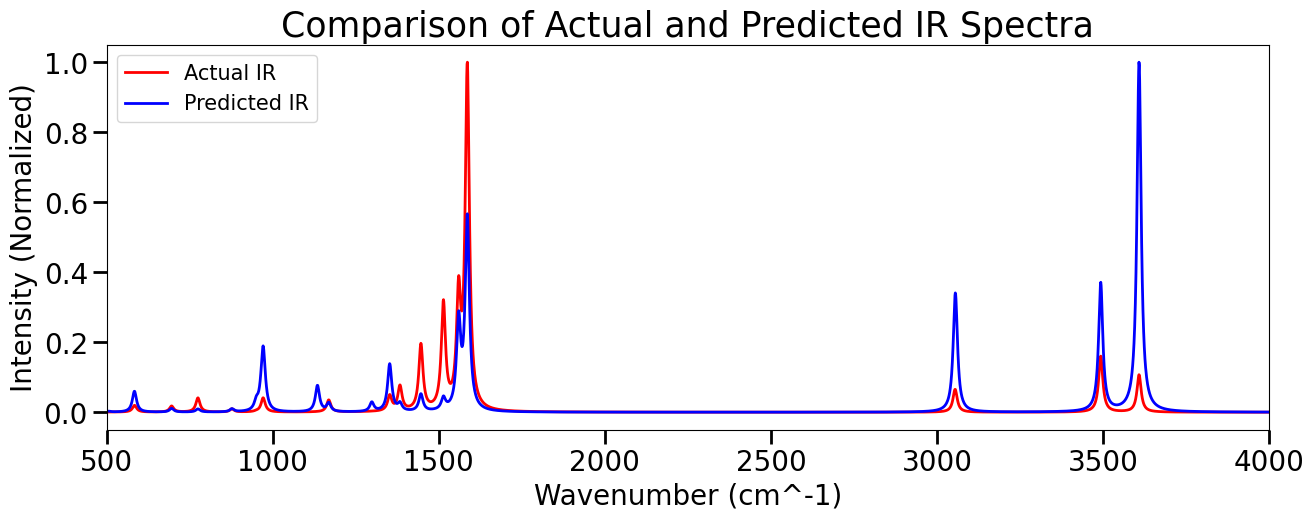

Mean Squared Error (MSE): 2.5662e+00
R²: 0.2313
Pearson Correlation Coefficient: 0.5805


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr


# 可视化实际光谱和预测光谱
plt.figure(figsize=(15, 5))
plt.plot(x, yir / np.max(yir), lw=2, label='Actual IR', color='r')  # 真实光谱
plt.plot(x, yir_pre / np.max(yir_pre), lw=2, label='Predicted IR', color='b')  # 预测光谱
plt.xlim(500, 4000)  # 设置x轴范围
plt.xlabel('Wavenumber (cm^-1)', fontsize=20)
plt.ylabel('Intensity (Normalized)', fontsize=20)
plt.legend(fontsize=15)
plt.tick_params(labelsize=20, width=2, length=10)
plt.title('Comparison of Actual and Predicted IR Spectra', fontsize=25)
plt.show()

# 计算均方误差 (MSE)
mse = mean_squared_error(yir, yir_pre)
print(f"Mean Squared Error (MSE): {mse:.4e}")

# 计算 R² 决定系数
r2 = r2_score(yir, yir_pre)
print(f"R²: {r2:.4f}")

# 计算皮尔逊相关系数 (PCC)
corr, _ = pearsonr(yir, yir_pre)
print(f"Pearson Correlation Coefficient: {corr:.4f}")



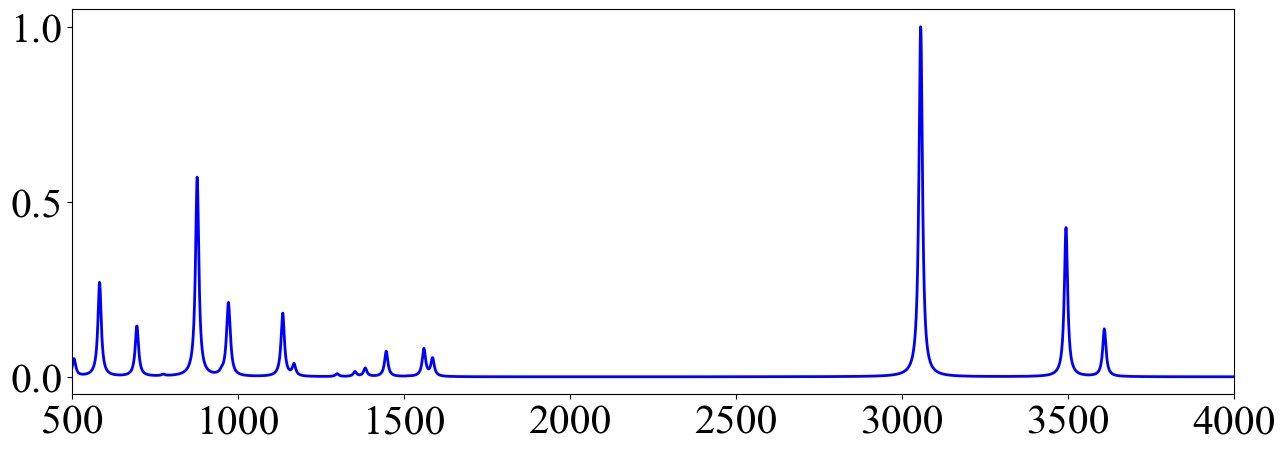

In [10]:
'''draw raman spectrum'''
plt.figure(figsize=(15,5))
plt.rc('font',family='Times New Roman', size=30)
plt.xlim(500,4000)
plt.plot(x,yraman/yraman.max(),lw=2,label='Raman',color='blue')

In [11]:
'''calculate uv spectrum'''
uv=uv_model_(z=z,pos=pos).detach().cpu().numpy()

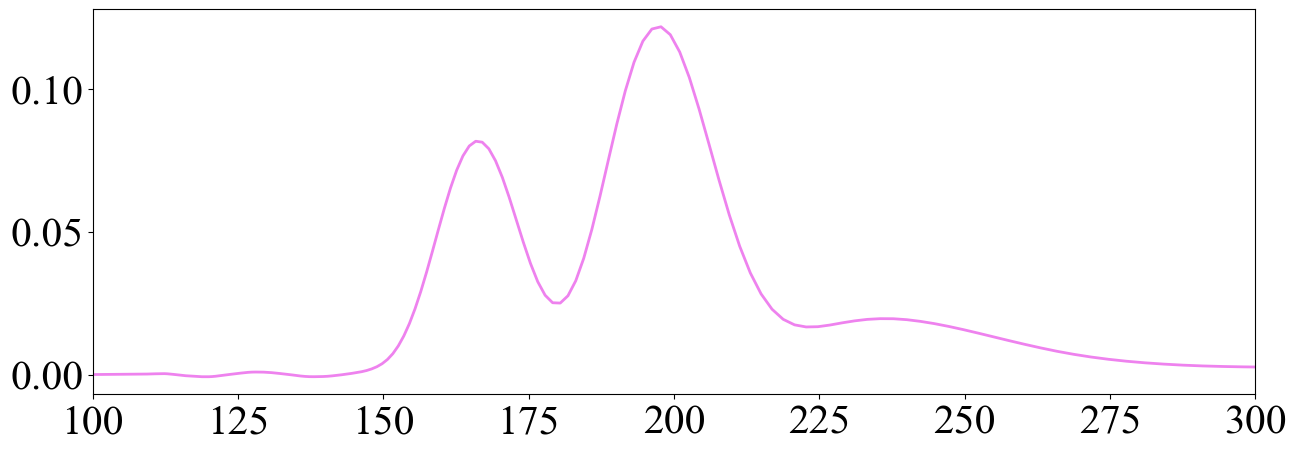

In [12]:
'''draw uv spectrum'''
xuv=1239.85/torch.linspace(1.5,13.5,240).detach().numpy()
plt.figure(figsize=(15,5))
plt.rc('font',family='Times New Roman', size=30)
plt.xlim(100,300)
plt.plot(xuv,uv,lw=2,color='Violet')